In [2]:
from model import Seq2SeqTransformer, FeatureExtractor
import torch
import torch.nn as nn
import torch.optim as optim
from dataloader import DocLayNetDataset
import random

N = 20
num_classes = 11

# set TOKENIZERS_PARALLELISM=false to avoid warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

dataset = DocLayNetDataset(split="test", rewrite_storage=False)
feature_extractor = FeatureExtractor(dataset)
pages_features, pages_targets = feature_extractor.get_page_features()
model = Seq2SeqTransformer(input_dim=N, output_dim=num_classes)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

features_and_targets = list(zip(pages_features, pages_targets))

random.shuffle(features_and_targets)
total = len(features_and_targets)
training_data = features_and_targets[:int(0.8 * total)]
validation_data = features_and_targets[int(0.8 * total):]
print(f"Training samples: {len(training_data)}, Validation samples: {len(validation_data)}")

100%|██████████| 4999/4999 [08:54<00:00,  9.36it/s]

Training samples: 3386, Validation samples: 847



/Users/shenjiajun/miniconda3/envs/ml2/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Iteration 100 | Validation Accuracy = 0.0000
Iteration 200 | Validation Accuracy = 0.0000
Iteration 300 | Validation Accuracy = 0.1264
Iteration 400 | Validation Accuracy = 0.2701
Iteration 500 | Validation Accuracy = 0.1897
Iteration 600 | Validation Accuracy = 0.1494
Iteration 700 | Validation Accuracy = 0.4770
Iteration 800 | Validation Accuracy = 0.2816
Iteration 900 | Validation Accuracy = 0.9368
Iteration 1000 | Validation Accuracy = 0.9425
Iteration 1100 | Validation Accuracy = 0.9425
Iteration 1200 | Validation Accuracy = 0.8966
Iteration 1300 | Validation Accuracy = 0.8908
Iteration 1400 | Validation Accuracy = 0.9425
Iteration 1500 | Validation Accuracy = 0.9253
Iteration 1600 | Validation Accuracy = 0.9425
Iteration 1700 | Validation Accuracy = 0.9425
Iteration 1800 | Validation Accuracy = 0.9425
Iteration 1900 | Validation Accuracy = 0.9425
Iteration 2000 | Validation Accuracy = 0.9425
Iteration 2100 | Validation Accuracy = 0.9310
Iteration 2200 | Validation Accuracy = 0.94

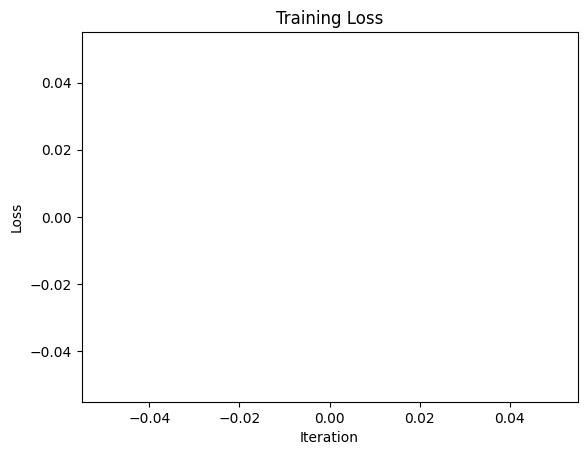

In [ ]:
EPOCHS = 1
losses = []
accuracies = []
for epoch in range(EPOCHS):
    for i, (page_features, targets) in enumerate(training_data):
        x, y = page_features, targets
        x = torch.tensor(x, dtype=torch.float32).reshape(N, -1)
        y = torch.tensor(y, dtype=torch.long)

        optimizer.zero_grad()
        pred = model(x) 
        loss = criterion(pred, y)
        losses.append(loss.item())
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # accuracy
        if (i + 1) % 100 == 0:
            for page_features_val, targets_val in validation_data:
                x_val = torch.tensor(page_features_val, dtype=torch.float32).reshape(N, -1)
                y_val = torch.tensor(targets_val, dtype=torch.long)
                with torch.no_grad():
                    pred_val = model(x_val)
                    _, predicted_val = torch.max(pred_val, dim=1)
                    correct_val = (predicted_val == y_val).sum().item()
                    accuracy = correct_val / y_val.size(0)

            print(f"Iteration {i+1} | Validation Accuracy = {accuracy:.4f}")
    print(f"Epoch {epoch} | Loss = {loss.item():.4f}, Accuracy = {accuracy:.4f}")


# Ignore, loss is empty plot
import matplotlib.pyplot as plt

context_size = 50
smoothed_losses = []
for i in range(len(losses), context_size):
    smoothed_losses.append(sum(losses[i - context_size:i]) / context_size)
    
plt.plot(smoothed_losses)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()